#### PRUEBAS MODELO CLASIFICACIÓN TIPO DE TAREA 

In [1]:
import pandas   as pd
import numpy    as np   
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../synthetic_data/synthetic_example.csv')

In [3]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit
0,Lee PLC,Little Redesign – Chocolate,26/10/2020,Complete,Peter Pugh,Design Issues,Urgent,Reporting a detail in Little Redesign – Chocol...,Desktop,Safari,https://www.littleredesign–chocolate.com,3,2,2.09
1,"Murphy, Wright and Jensen",Sign Landing – DarkOliveGreen,15/11/2024,Complete,Monica Edwards,New Item,Normal,"Monica Edwards, Murphy, Wright and Jensen – sm...",Mobile,Safari,https://www.signlanding–darkolivegreen.com,8,5,3.33
2,Wilson and Sons,Decide Website – MediumOrchid,20/11/2021,Complete,Christopher Durham,New Item,Urgent,"Christopher Durham, Wilson and Sons – small is...",Mobile,Firefox,https://www.decidewebsite–mediumorchid.com,8,6,3.77
3,"Sosa, Bell and King",Military Campaign – MediumSeaGreen,01/02/2020,Complete,Kenneth Hancock,Design Issues,High,"Hi all, reviewing Military Campaign – MediumSe...",Desktop,Chrome,https://www.militarycampaign–mediumseagreen.com,1,1,3.01
4,Monroe-Hinton,Everybody Landing – OrangeRed,18/03/2022,Complete,Tammy Steele,New Item,Urgent,Reporting a detail in Everybody Landing – Oran...,Mobile,Safari,https://www.everybodylanding–orangered.com,5,4,1.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Wilson and Sons,Rate Redesign – DarkSlateBlue,15/12/2021,Complete,Catherine Long,Copy Revision,Low,Noticed something odd in the contact form. Con...,Desktop,Edge,https://www.rateredesign–darkslateblue.com,1,1,3.77
9996,Miles LLC,Outside Platform – Red,23/10/2021,Complete,Bryan Frazier,Copy Revision,Low,Hi there! Bryan Frazier from Miles LLC here. T...,Desktop,Safari,https://www.outsideplatform–red.com,2,2,3.39
9997,Davis-Hernandez,Who Redesign – NavajoWhite,22/03/2024,Complete,Thomas Hoover,Requested Change,Normal,Reporting a detail in Who Redesign – NavajoWhi...,Desktop,Firefox,https://www.whoredesign–navajowhite.com,13,10,3.01
9998,Brown-Flores,Place Revamp – PaleGoldenRod,22/04/2024,Complete,Mark Woodard,New Item,Urgent,Hi! I’m looking at Place Revamp – PaleGoldenRo...,Desktop,Safari,https://www.placerevamp–palegoldenrod.com,8,6,3.77


In [4]:
# MINI EDA DEL REQUEST TYPE
df['Request Type'].value_counts()


Request Type
Requested Change    2606
New Item            2545
Design Issues       2442
Copy Revision       2407
Name: count, dtype: int64

<Axes: xlabel='Request Type', ylabel='count'>

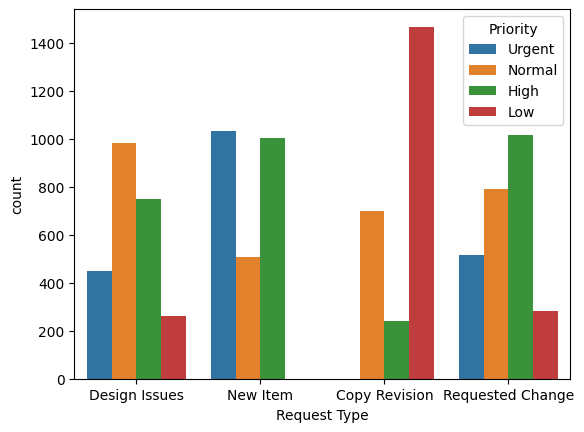

In [5]:
## VER LA CORRELACIÓN ENTRE rquest type y priority
sns.countplot(data=df, x='Request Type', hue='Priority')

c:\Users\Edurne\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


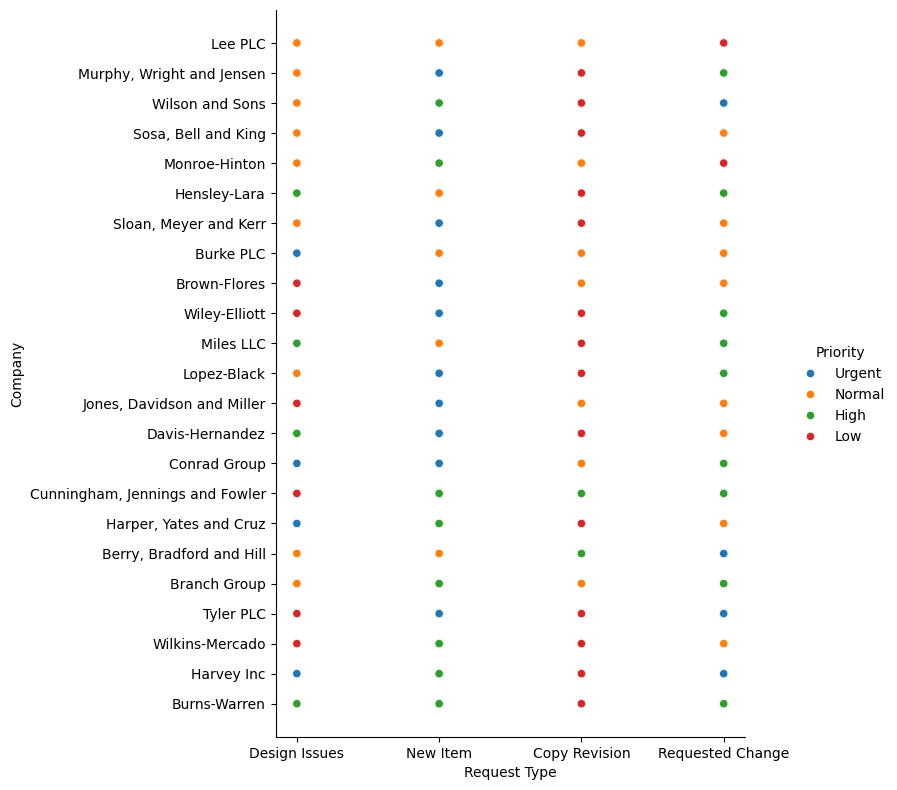

In [6]:
# correlacion entre Request Type y Company
sns.pairplot(data=df, x_vars='Request Type', y_vars='Company', hue='Priority', size=8)

<Axes: xlabel='Device'>

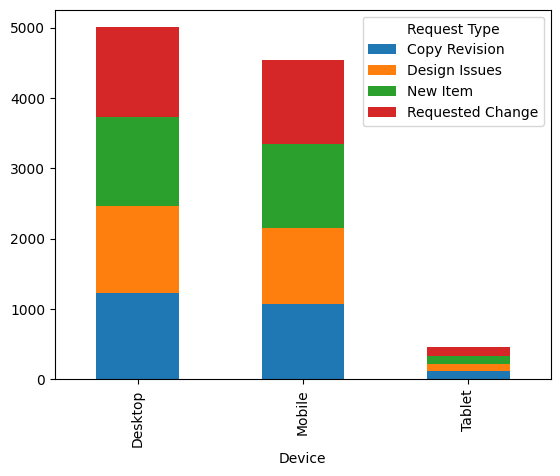

In [7]:
# correlacion entre Request Type y el Device

pd.crosstab(df['Device'], df['Request Type']).plot(kind='bar', stacked=True)

<Axes: xlabel='Request Type', ylabel='Browser'>

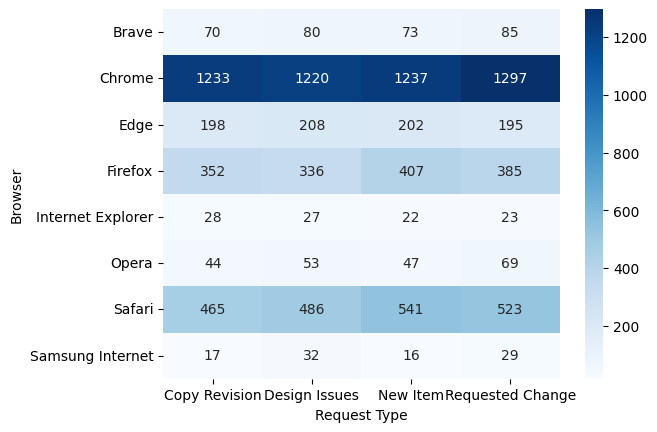

In [8]:
pivot = pd.crosstab(df['Browser'], df['Request Type'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='Month'>

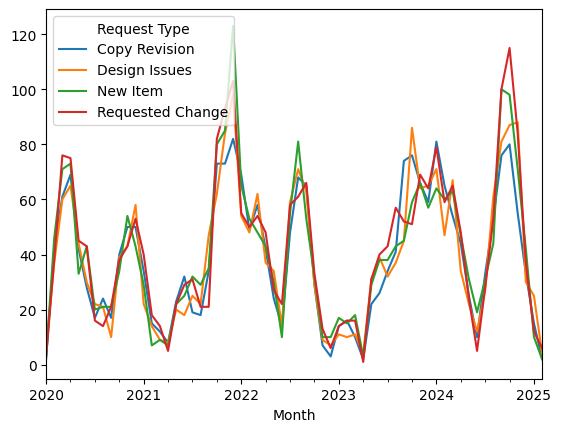

In [9]:
#series detiemp agrupadas por mes y año

df['Input Date'] = pd.to_datetime(df['Input Date'], dayfirst=True)
df['Month'] = df['Input Date'].dt.to_period('M')
df.groupby(['Month', 'Request Type']).size().unstack().plot()


<Axes: xlabel='Request Type', ylabel='Real Time'>

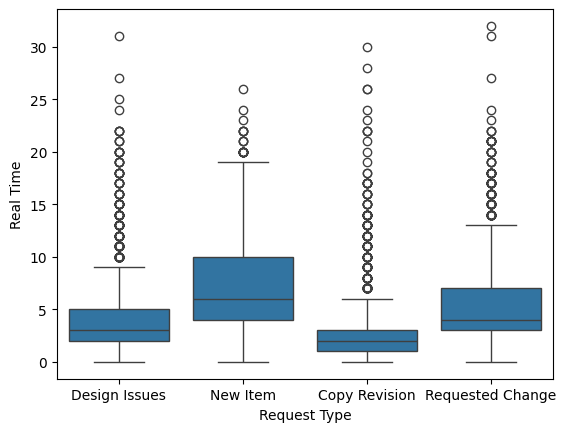

In [10]:
# ¿Qué tipo de solicitud tiende a tardar más o menos que lo estimado?
import seaborn as sns
sns.boxplot(x='Request Type', y='Real Time', data=df)

In [11]:
# para ver quién hace más solicitudesde cada tipo
top_requesters = df.groupby(['Request Type', 'Requester']).size().reset_index(name='Count')
top_requesters = top_requesters.sort_values(['Request Type', 'Count'], ascending=[True, False])


In [12]:
top_requesters

,Request Type,Requester,Count
1069,Copy Revision,John White,3
1589,Copy Revision,Melissa Smith,3
1627,Copy Revision,Michael Thompson,3
117,Copy Revision,Andrew Jones,2
124,Copy Revision,Andrew Taylor,2
...,...,...,...
9814,Requested Change,Zachary Braun,1
9815,Requested Change,Zachary Coleman,1
9816,Requested Change,Zachary Graves,1
9817,Requested Change,Zachary Hines,1


In [13]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit,Month
0,Lee PLC,Little Redesign – Chocolate,2020-10-26,Complete,Peter Pugh,Design Issues,Urgent,Reporting a detail in Little Redesign – Chocol...,Desktop,Safari,https://www.littleredesign–chocolate.com,3,2,2.09,2020-10
1,"Murphy, Wright and Jensen",Sign Landing – DarkOliveGreen,2024-11-15,Complete,Monica Edwards,New Item,Normal,"Monica Edwards, Murphy, Wright and Jensen – sm...",Mobile,Safari,https://www.signlanding–darkolivegreen.com,8,5,3.33,2024-11
2,Wilson and Sons,Decide Website – MediumOrchid,2021-11-20,Complete,Christopher Durham,New Item,Urgent,"Christopher Durham, Wilson and Sons – small is...",Mobile,Firefox,https://www.decidewebsite–mediumorchid.com,8,6,3.77,2021-11
3,"Sosa, Bell and King",Military Campaign – MediumSeaGreen,2020-02-01,Complete,Kenneth Hancock,Design Issues,High,"Hi all, reviewing Military Campaign – MediumSe...",Desktop,Chrome,https://www.militarycampaign–mediumseagreen.com,1,1,3.01,2020-02
4,Monroe-Hinton,Everybody Landing – OrangeRed,2022-03-18,Complete,Tammy Steele,New Item,Urgent,Reporting a detail in Everybody Landing – Oran...,Mobile,Safari,https://www.everybodylanding–orangered.com,5,4,1.74,2022-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Wilson and Sons,Rate Redesign – DarkSlateBlue,2021-12-15,Complete,Catherine Long,Copy Revision,Low,Noticed something odd in the contact form. Con...,Desktop,Edge,https://www.rateredesign–darkslateblue.com,1,1,3.77,2021-12
9996,Miles LLC,Outside Platform – Red,2021-10-23,Complete,Bryan Frazier,Copy Revision,Low,Hi there! Bryan Frazier from Miles LLC here. T...,Desktop,Safari,https://www.outsideplatform–red.com,2,2,3.39,2021-10
9997,Davis-Hernandez,Who Redesign – NavajoWhite,2024-03-22,Complete,Thomas Hoover,Requested Change,Normal,Reporting a detail in Who Redesign – NavajoWhi...,Desktop,Firefox,https://www.whoredesign–navajowhite.com,13,10,3.01,2024-03
9998,Brown-Flores,Place Revamp – PaleGoldenRod,2024-04-22,Complete,Mark Woodard,New Item,Urgent,Hi! I’m looking at Place Revamp – PaleGoldenRo...,Desktop,Safari,https://www.placerevamp–palegoldenrod.com,8,6,3.77,2024-04


In [14]:
# dividir train test split
from sklearn.model_selection import train_test_split
X = df['Request']
y = df['Request Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Pasos generales:**

Vectorización del texto (Request) – transformar el texto a una representación numérica (bag-of-words o TF-IDF).

Entrenamiento de un modelo de clasificación – por ejemplo, LogisticRegression, RandomForest, MultinomialNB, etc.

Evaluación del modelo – precisión, matriz de confusión, etc

In [15]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Preprocesar de forma automática el idioma usando un modelo multilingüe
# Usaremos un vectorizador simple y probaremos con un clasificador
# En lugar de 'stop_words="english"' y 'stop_words="spanish"', podemos optar por un solo modelo

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),  # Usamos TF-IDF sin especificar idioma para que capture ambos
    ('clf', LogisticRegression(max_iter=1000))  # Clasificador
])

# Entrenamiento
pipeline.fit(X_train, y_train)

# Evaluación
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


                  precision    recall  f1-score   support

   Copy Revision       0.87      0.90      0.88       487
   Design Issues       0.83      0.80      0.81       476
        New Item       0.84      0.87      0.86       501
Requested Change       0.85      0.81      0.83       536

        accuracy                           0.85      2000
       macro avg       0.85      0.85      0.85      2000
    weighted avg       0.85      0.85      0.85      2000



In [16]:
request_ejemplo = "Please update the homepage banner to reflect the new campaign launch."


prediction = pipeline.predict([request_ejemplo])
print(f"Request: {request_ejemplo}")
print(f"Predicted Request Type: {prediction[0]}")


Request: Please update the homepage banner to reflect the new campaign launch.
Predicted Request Type: New Item


In [17]:
request_2 = "There is a typo in the About Us section that needs correction."

prediction = pipeline.predict([request_2])
print(f"Request: {request_2}")
print(f"Predicted Request Type: {prediction[0]}")

Request: There is a typo in the About Us section that needs correction.
Predicted Request Type: Copy Revision


In [18]:
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Codificar etiquetas categóricas a números
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Crear pipeline
pipeline_xgb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('xgb', XGBClassifier())
])

# Entrenar con etiquetas codificadas
pipeline_xgb.fit(X_train, y_train_encoded)

# Predecir con etiquetas codificadas
y_pred_encoded = pipeline_xgb.predict(X_test)

# Opcional: para ver las etiquetas originales de la predicción
y_pred = le.inverse_transform(y_pred_encoded)

# Mostrar reporte de métricas 
print(classification_report(y_test_encoded, y_pred_encoded, target_names=le.classes_))

                  precision    recall  f1-score   support

   Copy Revision       0.87      0.92      0.89       487
   Design Issues       0.84      0.78      0.81       476
        New Item       0.86      0.86      0.86       501
Requested Change       0.82      0.84      0.83       536

        accuracy                           0.85      2000
       macro avg       0.85      0.85      0.85      2000
    weighted avg       0.85      0.85      0.85      2000



In [19]:
import pickle

# Empaquetar modelo y encoder juntos
model_bundle = {
    "model": pipeline_xgb,
    "label_encoder": le
}

# Guardar como un solo archivo
with open('xgb_model_request_type.pkl', 'wb') as file:
    pickle.dump(model_bundle, file)

In [20]:
# # Guardar el modelo entrenado
# with open('xgb_model_request_type.pkl', 'wb') as file:
#     pickle.dump(pipeline_xgb, file)


In [21]:
#!pip install transformers 

In [22]:
#!pip install transformers torch

In [23]:
#!pip install sentencepiece
